# Results Analysis — xCPE-TimeDART vs Baselines

Reads `results/tables/etth1_results.csv` **and** `results/tables/weather_results.csv`
(mean ± std over 3 seeds) and produces comparison figures across both datasets.

1. **Bar chart** — MSE per variant at H=96 (ETTh1 vs Weather)
2. **Line chart** — MSE vs horizon per variant (both datasets)
3. **Error bar plot** — mean ± std per variant × horizon (both datasets)
4. **Improvement heatmap** — % MSE change vs baseline (shared colorscale)
5. **MSE + MAE dual metric** — at H=96, both datasets (2×2 grid)
6. **Per-horizon bar grid** — all variants, both datasets (2×4 grid)
7. **Absolute advantage lines** — baseline − variant MSE (both datasets)
8. **Ranking heatmap** — per-horizon ranks (both datasets)
9. **Cross-dataset gain scaling** — xCPE improvement % grows with horizon, larger on Weather

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})

ETTH1_PATH   = Path('../results/tables/etth1_results.csv')
WEATHER_PATH = Path('../results/tables/weather_results.csv')
FIGURES_PATH = Path('../results/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

df_etth1   = pd.read_csv(ETTH1_PATH)
df_weather = pd.read_csv(WEATHER_PATH)
DATASETS   = {'ETTh1': df_etth1, 'Weather': df_weather}

print(f'ETTh1 rows: {len(df_etth1)}  |  Weather rows: {len(df_weather)}')
df_etth1.head()

ETTh1 rows: 20  |  Weather rows: 20


,variant,horizon,n_seeds,mse_mean,mse_std,mae_mean,mae_std
0,baseline,96,3,0.4185,0.0025,0.4479,0.0017
1,baseline,192,3,0.4656,0.0033,0.4828,0.0016
2,baseline,336,3,0.5207,0.0015,0.5181,0.0020
3,baseline,720,3,0.6385,0.0100,0.5948,0.0049
4,rope,96,3,0.4249,0.0071,0.4573,0.0075


In [24]:
# ── Palette and display names ────────────────────────────────────────────────
VARIANT_ORDER = ['baseline', 'xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']
DISPLAY_NAMES = {
    'baseline':   'Baseline',
    'xcpe_all':   'xCPE (all)',
    'xcpe_early': 'xCPE (early)',
    'xcpe_late':  'xCPE (late)',
    'rope':       'RoPE',
}
PALETTE = {
    'baseline':   '#4C72B0',
    'xcpe_all':   '#DD8452',
    'xcpe_early': '#55A868',
    'xcpe_late':  '#C44E52',
    'rope':       '#8172B2',
}
HORIZONS = [96, 192, 336, 720]

## Figure 1 — Bar chart: MSE at H=96 (ETTh1 vs Weather)

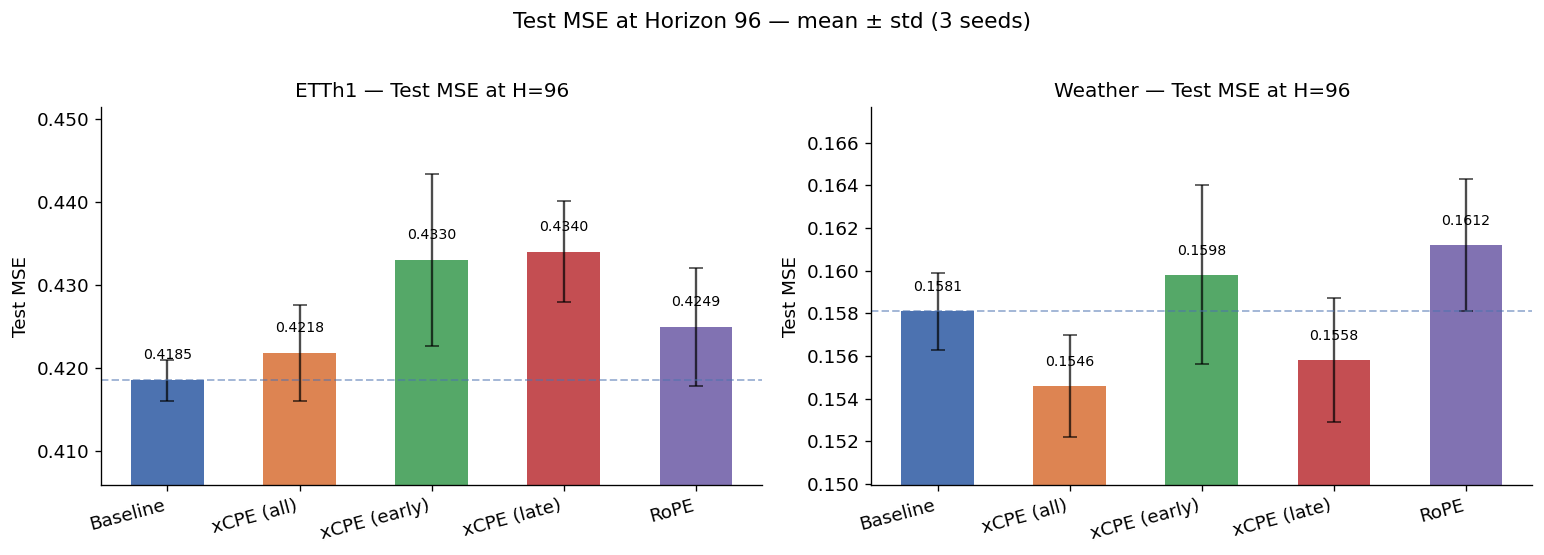

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    h96  = df[df['horizon'] == 96].set_index('variant').reindex(VARIANT_ORDER)
    x    = np.arange(len(VARIANT_ORDER))
    bump = h96['mse_mean'].max() * 0.005
    bars = ax.bar(
        x, h96['mse_mean'], yerr=h96['mse_std'], capsize=4,
        color=[PALETTE[v] for v in VARIANT_ORDER], width=0.55,
        error_kw={'elinewidth': 1.4, 'ecolor': 'black', 'alpha': 0.7},
    )
    for bar, val in zip(bars, h96['mse_mean']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.axhline(h96.loc['baseline', 'mse_mean'], color=PALETTE['baseline'],
               linestyle='--', linewidth=1.2, alpha=0.5, label='Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels([DISPLAY_NAMES[v] for v in VARIANT_ORDER], rotation=15, ha='right')
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — Test MSE at H=96')
    ax.set_ylim(h96['mse_mean'].min() * 0.97, h96['mse_mean'].max() * 1.04)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Test MSE at Horizon 96 — mean ± std (3 seeds)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig1_bar_mse_h96.png', bbox_inches='tight')
plt.show()

## Figure 2 — Line chart: MSE vs horizon per variant (both datasets)

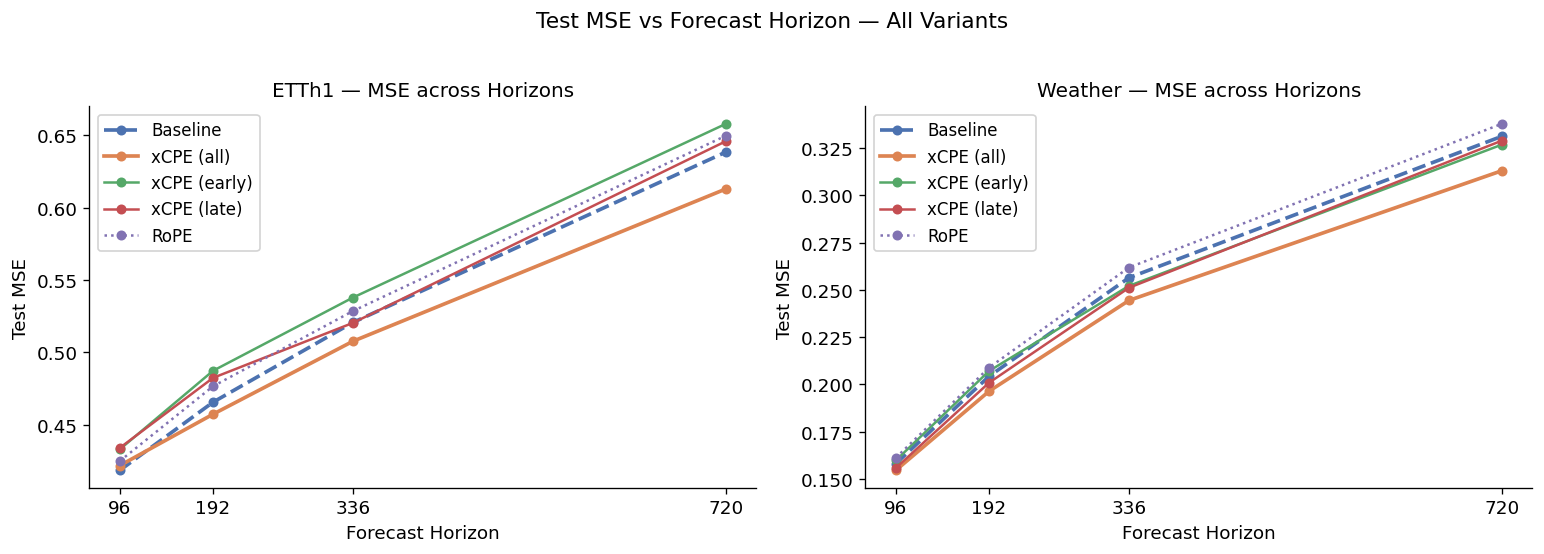

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (dset, df) in zip(axes, DATASETS.items()):
    for variant in VARIANT_ORDER:
        vdf = df[df['variant'] == variant].sort_values('horizon')
        ls  = '-' if 'xcpe' in variant else ('--' if variant == 'baseline' else ':')
        lw  = 2.2 if variant in ('baseline', 'xcpe_all') else 1.5
        ax.plot(vdf['horizon'], vdf['mse_mean'],
                marker='o', markersize=5,
                color=PALETTE[variant], linestyle=ls, linewidth=lw,
                label=DISPLAY_NAMES[variant])
    ax.set_xticks(HORIZONS)
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — MSE across Horizons')
    ax.legend(loc='upper left', framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Test MSE vs Forecast Horizon — All Variants', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig2_line_mse_horizons.png', bbox_inches='tight')
plt.show()

## Figure 3 — Error bar plot: MSE mean ± std per variant × horizon (both datasets)

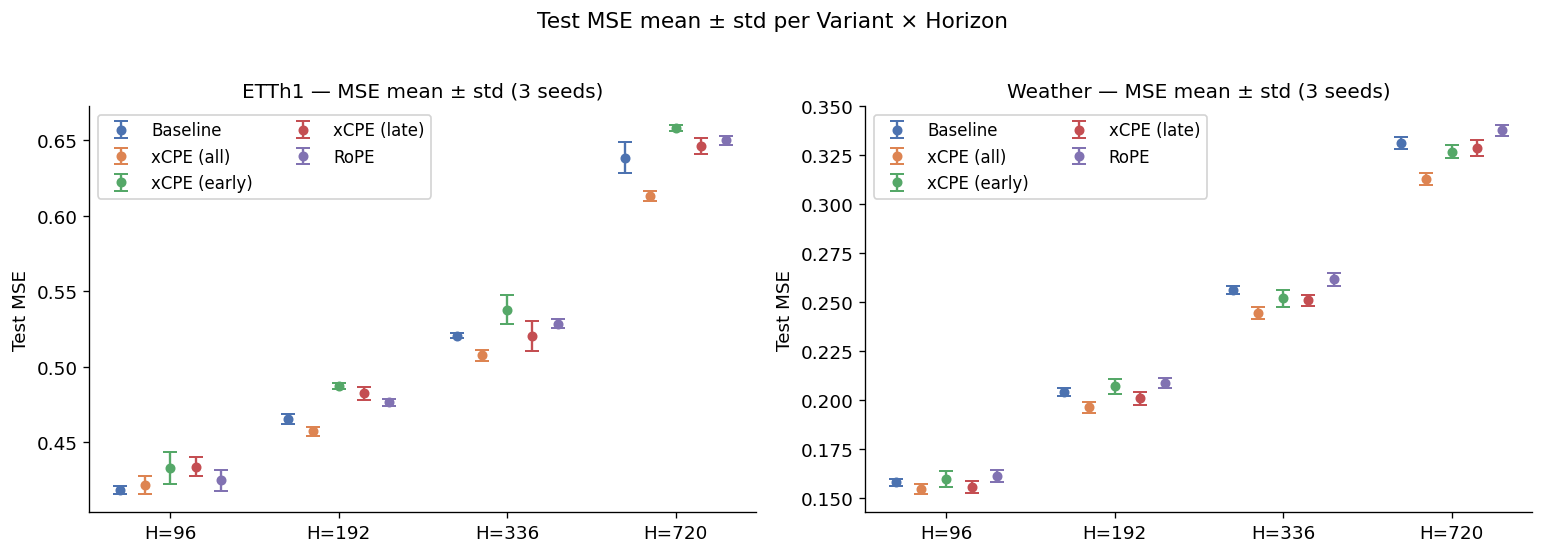

In [27]:
n_variants = len(VARIANT_ORDER)
width      = 0.15
offsets    = np.linspace(-(n_variants - 1) / 2, (n_variants - 1) / 2, n_variants) * width

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (dset, df) in zip(axes, DATASETS.items()):
    x = np.arange(len(HORIZONS))
    for i, variant in enumerate(VARIANT_ORDER):
        vdf = df[df['variant'] == variant].sort_values('horizon')
        ax.errorbar(
            x + offsets[i], vdf['mse_mean'].values, yerr=vdf['mse_std'].values,
            fmt='o', markersize=5, color=PALETTE[variant],
            capsize=4, capthick=1.2, linewidth=1.4,
            label=DISPLAY_NAMES[variant],
        )
    ax.set_xticks(x)
    ax.set_xticklabels([f'H={h}' for h in HORIZONS])
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — MSE mean ± std (3 seeds)')
    ax.legend(loc='upper left', framealpha=0.85, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Test MSE mean ± std per Variant × Horizon', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig3_errorbar_mse.png', bbox_inches='tight')
plt.show()

## Figure 4 — Improvement heatmap: variants vs Baseline (both datasets, shared colorscale)

Relative MSE change: `(variant − baseline) / baseline × 100%`  
Negative = improvement. Shared colorscale enables direct cross-dataset comparison.

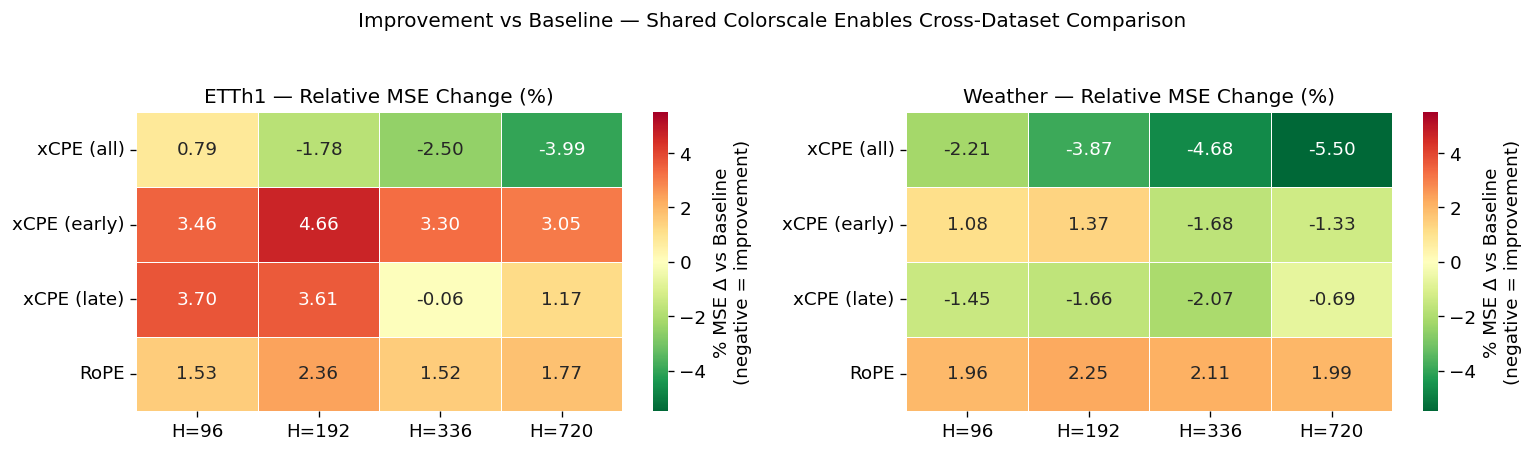

In [28]:
compare_variants = ['xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']

def build_heatmap_df(df):
    base = df[df['variant'] == 'baseline'].set_index('horizon')['mse_mean']
    rows = []
    for v in compare_variants:
        vdf = df[df['variant'] == v].set_index('horizon')
        rows.append([(vdf.loc[h, 'mse_mean'] - base[h]) / base[h] * 100 for h in HORIZONS])
    return pd.DataFrame(rows,
                        index=[DISPLAY_NAMES[v] for v in compare_variants],
                        columns=[f'H={h}' for h in HORIZONS])

hm_etth1   = build_heatmap_df(df_etth1)
hm_weather = build_heatmap_df(df_weather)
# Shared symmetric color range for direct cross-dataset comparison
vabs = max(hm_etth1.abs().values.max(), hm_weather.abs().values.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

for ax, hm, dset in zip(axes, [hm_etth1, hm_weather], DATASETS.keys()):
    sns.heatmap(
        hm, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r',
        center=0, vmin=-vabs, vmax=vabs, linewidths=0.5,
        cbar_kws={'label': '% MSE Δ vs Baseline\n(negative = improvement)'},
    )
    ax.set_title(f'{dset} — Relative MSE Change (%)')
    ax.set_ylabel('')

fig.suptitle('Improvement vs Baseline — Shared Colorscale Enables Cross-Dataset Comparison',
             fontsize=12, y=1.04)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig4_improvement_heatmap.png', bbox_inches='tight')
plt.show()

## Figure 5 — MSE and MAE at H=96 (both datasets, 2×2 grid)

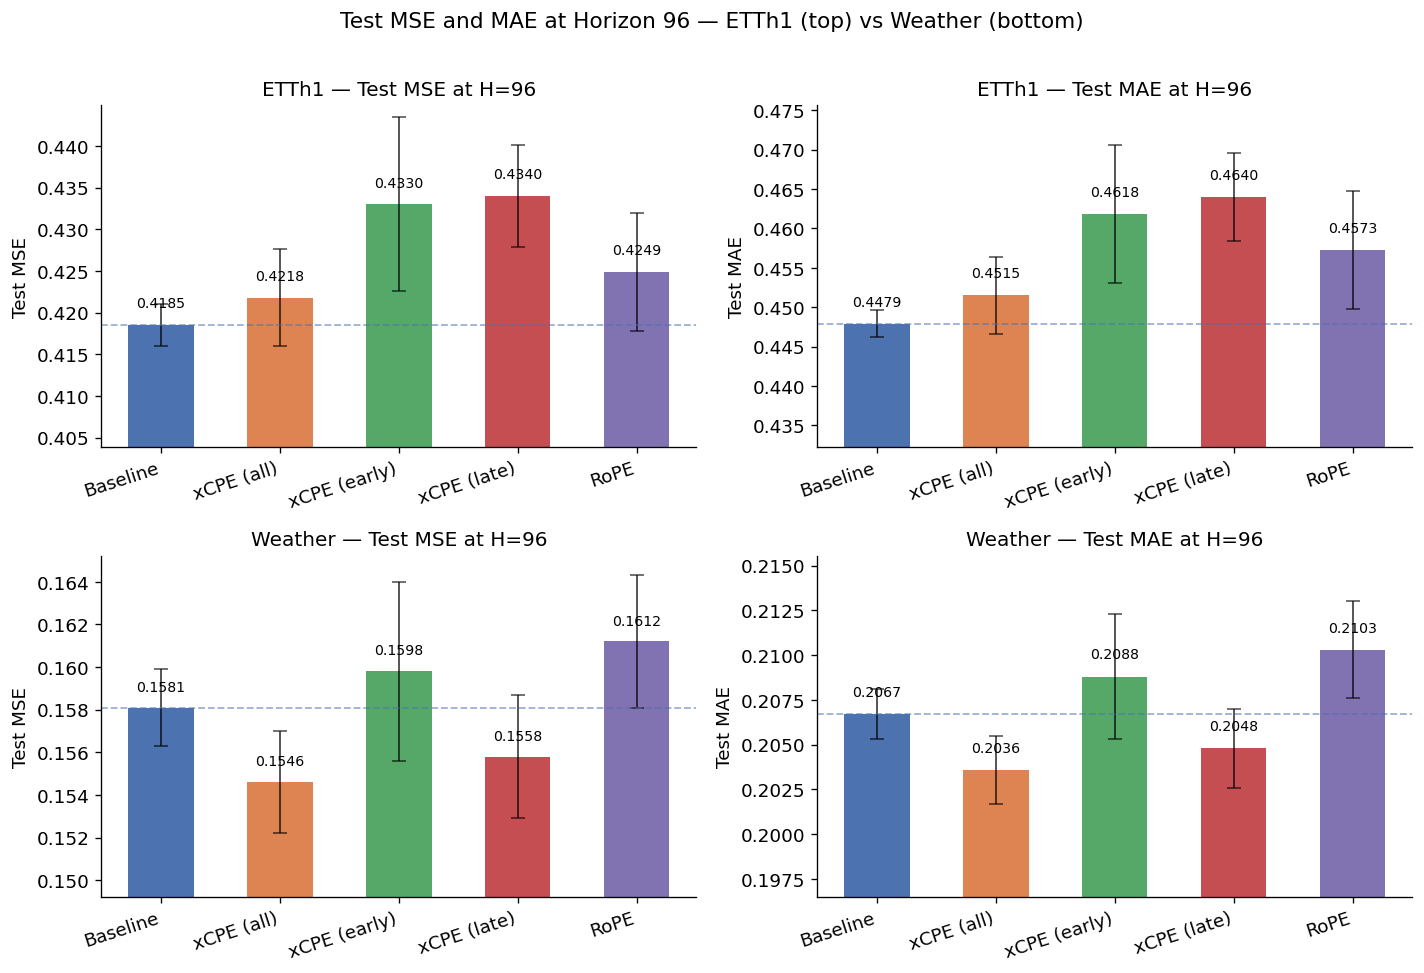

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x      = np.arange(len(VARIANT_ORDER))
colors = [PALETTE[v] for v in VARIANT_ORDER]

for row_i, (dset, df) in enumerate(DATASETS.items()):
    h96 = df[df['horizon'] == 96].set_index('variant').reindex(VARIANT_ORDER)
    for col_i, (metric, std_col, label) in enumerate([
        ('mse_mean', 'mse_std', 'Test MSE'),
        ('mae_mean', 'mae_std', 'Test MAE'),
    ]):
        ax   = axes[row_i, col_i]
        bump = h96[metric].max() * 0.004
        bars = ax.bar(x, h96[metric], yerr=h96[std_col], capsize=4,
                      color=colors, width=0.55,
                      error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.65})
        for bar, val in zip(bars, h96[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
        ax.axhline(h96.loc['baseline', metric], color=PALETTE['baseline'],
                   linestyle='--', linewidth=1.1, alpha=0.55)
        ax.set_xticks(x)
        ax.set_xticklabels([DISPLAY_NAMES[v] for v in VARIANT_ORDER], rotation=18, ha='right')
        ax.set_ylabel(label)
        ax.set_title(f'{dset} — {label} at H=96')
        ax.set_ylim(h96[metric].min() * 0.965, h96[metric].max() * 1.025)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Test MSE and MAE at Horizon 96 — ETTh1 (top) vs Weather (bottom)',
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig5_dual_metric_h96.png', bbox_inches='tight')
plt.show()

## Figure 6 — Per-horizon bar grid: all variants, both datasets (2 rows × 4 horizons)

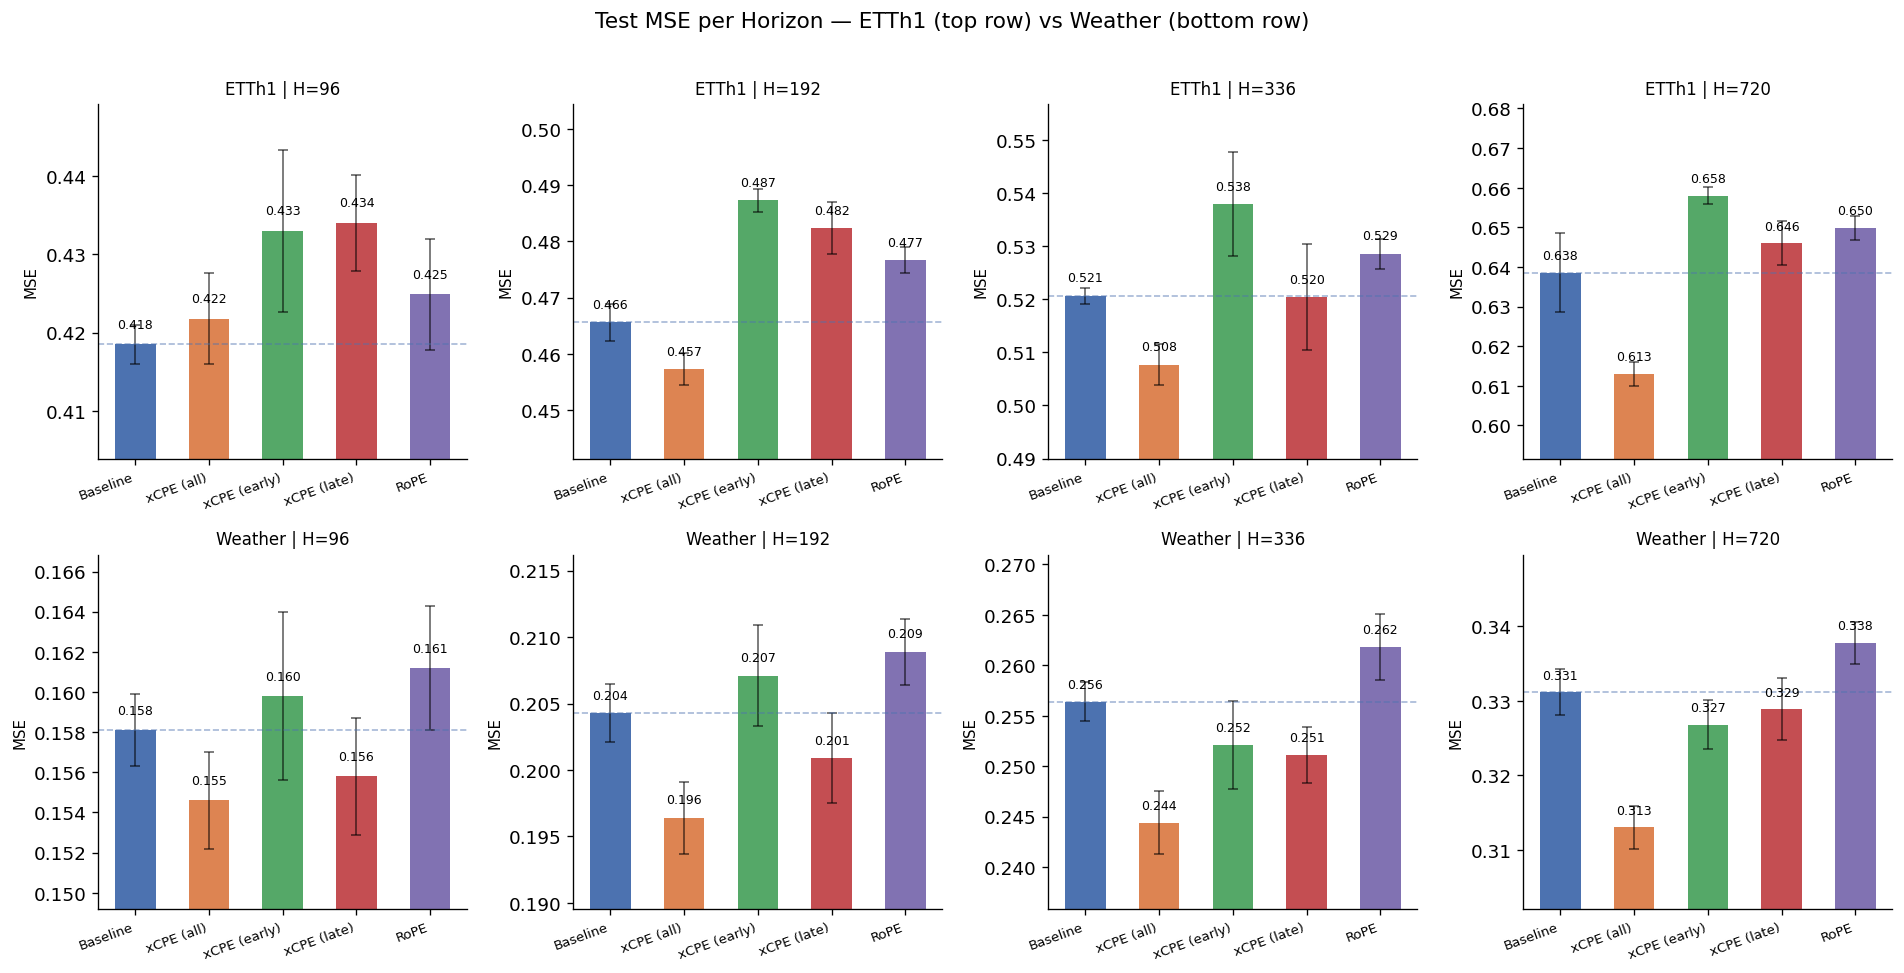

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
x      = np.arange(len(VARIANT_ORDER))
colors = [PALETTE[v] for v in VARIANT_ORDER]

for row_i, (dset, df) in enumerate(DATASETS.items()):
    for col_i, horizon in enumerate(HORIZONS):
        ax   = axes[row_i, col_i]
        hdf  = df[df['horizon'] == horizon].set_index('variant').reindex(VARIANT_ORDER)
        bump = hdf['mse_mean'].max() * 0.004
        bars = ax.bar(x, hdf['mse_mean'], yerr=hdf['mse_std'], capsize=3,
                      color=colors, width=0.55,
                      error_kw={'elinewidth': 1.0, 'ecolor': 'black', 'alpha': 0.6})
        for bar, val in zip(bars, hdf['mse_mean']):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
        ax.axhline(hdf.loc['baseline', 'mse_mean'], color=PALETTE['baseline'],
                   linestyle='--', linewidth=1.0, alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([DISPLAY_NAMES[v] for v in VARIANT_ORDER],
                           rotation=20, ha='right', fontsize=8)
        ax.set_ylabel('MSE', fontsize=9)
        ax.set_title(f'{dset} | H={horizon}', fontsize=10)
        ax.set_ylim(hdf['mse_mean'].min() * 0.965, hdf['mse_mean'].max() * 1.035)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Test MSE per Horizon — ETTh1 (top row) vs Weather (bottom row)',
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig6_per_horizon_grid.png', bbox_inches='tight')
plt.show()

## Figure 7 — Absolute MSE advantage over Baseline (both datasets)

`advantage = baseline_MSE − variant_MSE`  (positive = better than baseline)

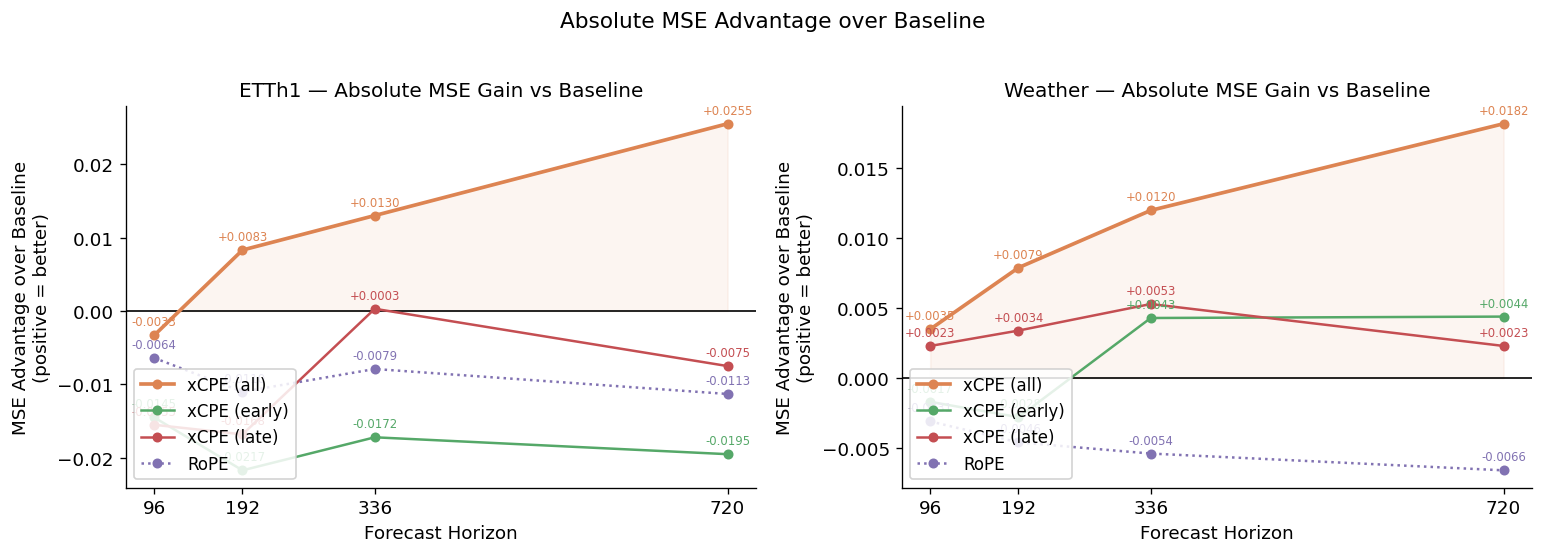

In [31]:
compare = ['xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    base_ser = df[df['variant'] == 'baseline'].set_index('horizon')['mse_mean']
    ax.axhline(0, color='black', linewidth=1.0)

    for variant in compare:
        vdf = df[df['variant'] == variant].sort_values('horizon')
        advantage = [base_ser[h] - vdf.set_index('horizon').loc[h, 'mse_mean']
                     for h in HORIZONS]
        ls = '-' if 'xcpe' in variant else ':'
        lw = 2.2 if variant == 'xcpe_all' else 1.5
        ax.plot(HORIZONS, advantage, marker='o', markersize=5,
                color=PALETTE[variant], linestyle=ls, linewidth=lw,
                label=DISPLAY_NAMES[variant])
        for h, adv in zip(HORIZONS, advantage):
            ax.annotate(f'{adv:+.4f}', xy=(h, adv), xytext=(0, 6),
                        textcoords='offset points',
                        ha='center', fontsize=7, color=PALETTE[variant])

    # Shade region where xcpe_all beats baseline
    xcpe_adv = [base_ser[h] - df[(df['variant']=='xcpe_all') & (df['horizon']==h)]['mse_mean'].values[0]
                for h in HORIZONS]
    ax.fill_between(HORIZONS, xcpe_adv, 0, where=[a > 0 for a in xcpe_adv],
                    alpha=0.08, color=PALETTE['xcpe_all'], interpolate=True)

    ax.set_xticks(HORIZONS)
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('MSE Advantage over Baseline\n(positive = better)')
    ax.set_title(f'{dset} — Absolute MSE Gain vs Baseline')
    ax.legend(loc='lower left', framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Absolute MSE Advantage over Baseline', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig7_advantage_lines.png', bbox_inches='tight')
plt.show()

## Figure 8 — Ranking heatmap: rank 1 = lowest MSE (both datasets)

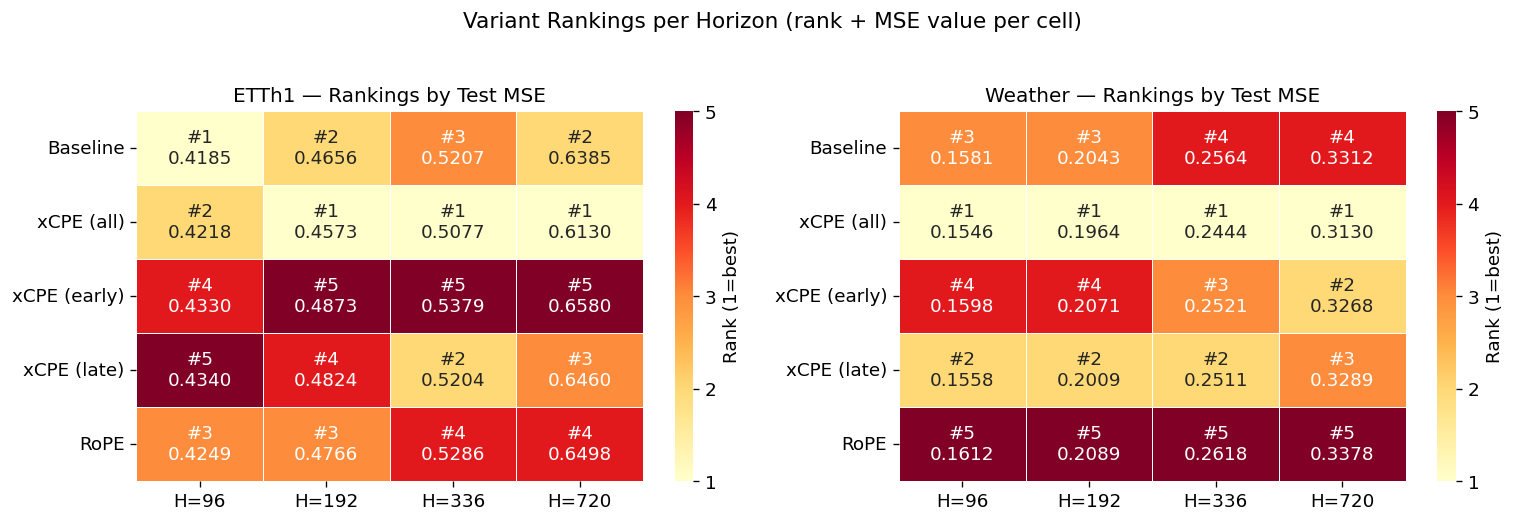

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    rank_rows = []
    for variant in VARIANT_ORDER:
        row = []
        for horizon in HORIZONS:
            hdf  = df[df['horizon'] == horizon].sort_values('mse_mean').reset_index(drop=True)
            rank = hdf[hdf['variant'] == variant].index[0] + 1
            row.append(rank)
        rank_rows.append(row)

    rank_df = pd.DataFrame(rank_rows,
                           index=[DISPLAY_NAMES[v] for v in VARIANT_ORDER],
                           columns=[f'H={h}' for h in HORIZONS])

    annot = pd.DataFrame(index=rank_df.index, columns=rank_df.columns, dtype=object)
    for variant, dname in zip(VARIANT_ORDER, rank_df.index):
        for horizon, col in zip(HORIZONS, rank_df.columns):
            mse = df[(df['variant']==variant) & (df['horizon']==horizon)]['mse_mean'].values[0]
            annot.loc[dname, col] = f'#{rank_df.loc[dname, col]}\n{mse:.4f}'

    sns.heatmap(rank_df.astype(float), ax=ax, annot=annot, fmt='',
                cmap='YlOrRd', vmin=1, vmax=len(VARIANT_ORDER), linewidths=0.6,
                cbar_kws={'label': 'Rank (1=best)', 'ticks': list(range(1, len(VARIANT_ORDER)+1))})
    ax.set_title(f'{dset} — Rankings by Test MSE')
    ax.set_ylabel('')

fig.suptitle('Variant Rankings per Horizon (rank + MSE value per cell)', fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig8_ranking_heatmap.png', bbox_inches='tight')
plt.show()

## Figure 9 — Cross-dataset gain scaling

xCPE (all) MSE improvement over baseline as a function of horizon, for both datasets.  
**Key narrative:** gains grow with horizon on both datasets; consistently larger on Weather (21 vars, non-stationary) than ETTh1 (7 vars, periodic).

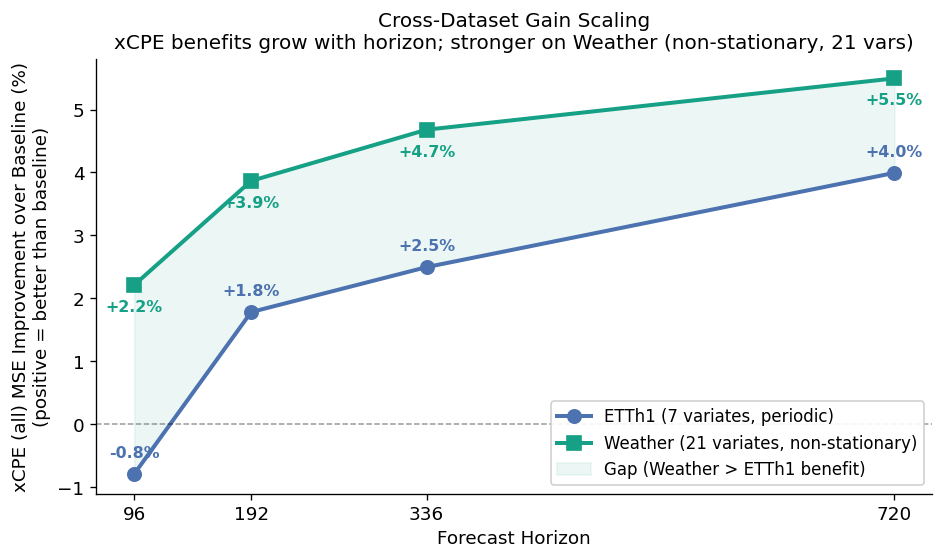


Horizon      ETTh1 gain   Weather gain
--------------------------------------
H=96            -0.79%         +2.21%
H=192           +1.78%         +3.87%
H=336           +2.50%         +4.68%
H=720           +3.99%         +5.50%


In [33]:
fig, ax = plt.subplots(figsize=(8, 4.8))

COLOR_ETTH1   = PALETTE['baseline']   # blue — reuse for ETTh1 line
COLOR_WEATHER = '#16A085'             # teal — distinct from all variant colors

base_e = df_etth1[df_etth1['variant']=='baseline'].set_index('horizon')['mse_mean']
xcpe_e = df_etth1[df_etth1['variant']=='xcpe_all'].set_index('horizon')['mse_mean']
gain_etth1 = [(base_e[h] - xcpe_e[h]) / base_e[h] * 100 for h in HORIZONS]

base_w = df_weather[df_weather['variant']=='baseline'].set_index('horizon')['mse_mean']
xcpe_w = df_weather[df_weather['variant']=='xcpe_all'].set_index('horizon')['mse_mean']
gain_weather = [(base_w[h] - xcpe_w[h]) / base_w[h] * 100 for h in HORIZONS]

ax.plot(HORIZONS, gain_etth1, marker='o', markersize=8, linewidth=2.4,
        color=COLOR_ETTH1, linestyle='-', label='ETTh1 (7 variates, periodic)')
ax.plot(HORIZONS, gain_weather, marker='s', markersize=8, linewidth=2.4,
        color=COLOR_WEATHER, linestyle='-', label='Weather (21 variates, non-stationary)')

for h, g in zip(HORIZONS, gain_etth1):
    ax.annotate(f'{g:+.1f}%', xy=(h, g), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9.5,
                color=COLOR_ETTH1, fontweight='bold')
for h, g in zip(HORIZONS, gain_weather):
    ax.annotate(f'{g:+.1f}%', xy=(h, g), xytext=(0, -16),
                textcoords='offset points', ha='center', fontsize=9.5,
                color=COLOR_WEATHER, fontweight='bold')

ax.fill_between(HORIZONS, gain_weather, gain_etth1,
                alpha=0.08, color=COLOR_WEATHER, label='Gap (Weather > ETTh1 benefit)')
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.4)

ax.set_xticks(HORIZONS)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('xCPE (all) MSE Improvement over Baseline (%)\n(positive = better than baseline)')
ax.set_title('Cross-Dataset Gain Scaling\n'
             'xCPE benefits grow with horizon; stronger on Weather (non-stationary, 21 vars)',
             fontsize=12)
ax.legend(framealpha=0.9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_PATH / 'fig9_crossdataset_gain_scaling.png', bbox_inches='tight')
plt.show()

print(f"\n{'Horizon':<10} {'ETTh1 gain':>12} {'Weather gain':>14}")
print('-' * 38)
for h, ge, gw in zip(HORIZONS, gain_etth1, gain_weather):
    print(f"H={h:<7} {ge:>+11.2f}%  {gw:>+12.2f}%")

In [34]:
from IPython.display import display

for dset, df in DATASETS.items():
    print(f'\n{"="*60}')
    print(f'  {dset}')
    print(f'{"="*60}')
    pivot = df.pivot_table(index='variant', columns='horizon',
                           values=['mse_mean', 'mae_mean'])
    pivot = pivot.reindex(VARIANT_ORDER)
    pivot.index = [DISPLAY_NAMES[v] for v in VARIANT_ORDER]
    display(pivot.round(4))


  ETTh1


mae_mean                         mse_mean                        
horizon           96      192     336     720      96      192     336     720
Baseline       0.4479  0.4828  0.5181  0.5948   0.4185  0.4656  0.5207  0.6385
xCPE (all)     0.4515  0.4741  0.5092  0.5787   0.4218  0.4573  0.5077  0.6130
xCPE (early)   0.4618  0.4986  0.5300  0.6039   0.4330  0.4873  0.5379  0.6580
xCPE (late)    0.4640  0.4971  0.5207  0.5997   0.4340  0.4824  0.5204  0.6460
RoPE           0.4573  0.4934  0.5285  0.6027   0.4249  0.4766  0.5286  0.6498


  Weather


mae_mean                         mse_mean                        
horizon           96      192     336     720      96      192     336     720
Baseline       0.2067  0.2498  0.2894  0.3469   0.1581  0.2043  0.2564  0.3312
xCPE (all)     0.2036  0.2435  0.2801  0.3337   0.1546  0.1964  0.2444  0.3130
xCPE (early)   0.2088  0.2527  0.2849  0.3425   0.1598  0.2071  0.2521  0.3268
xCPE (late)    0.2048  0.2462  0.2831  0.3447   0.1558  0.2009  0.2511  0.3289
RoPE           0.2103  0.2544  0.2946  0.3512   0.1612  0.2089  0.2618  0.3378

## Summary tables — ETTh1 and Weather